In [ ]:
pip install alpaca-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 2.8 MB/s eta 0:00:00


### 1. Requisitos Previos y Configuración

Antes de escribir código, necesitas tus credenciales de Alpaca. Te recomiendo probar siempre en el entorno de simulación (Paper Trading).

- Inicia sesión en tu cuenta de Alpaca y ve al dashboard de Paper Trading.

- Genera tus llaves API. Obtendrás un API Key y un Secret Key.

- Instala la biblioteca oficial en la terminal

### 2. Estructura de alpaca-py
La biblioteca se divide en tres pilares principales. Dependiendo de lo que quieras hacer, importarás un cliente diferente:

- `alpaca.trading`: Para consultar tu cuenta, ver posiciones y enviar órdenes (comprar/vender).

- `alpaca.data`: Para obtener datos históricos y en tiempo real de acciones y criptomonedas.

- `alpaca.broker`: Para revender los servicios de Alpaca (uso avanzado/institucional).

### 3. Conexión a la Cuenta y Gestión de Órdenes
Vamos a empezar con el módulo de Trading. Lo primero es autenticarnos y revisar el estado de nuestra cuenta.

In [ ]:
from alpaca.trading.client import TradingClient
from google.colab import userdata

# Reemplaza con tus llaves reales o usa variables de entorno (recomendado)
API_KEY = userdata.get("ALPACA_KEY")
SECRET_KEY = userdata.get("ALPACA_SECRET")

# 'paper=True' le dice al SDK que use el entorno de simulación
trading_client = TradingClient(API_KEY, SECRET_KEY, paper=True)

In [ ]:
# Obtener información de la cuenta
account = trading_client.get_account()
print(f"Saldo disponible para operar: ${account.cash}")
print(f"Valor total del portafolio: ${account.portfolio_value}")

Saldo disponible para operar: $99378.82
Valor total del portafolio: $99999.07


### Crear y Enviar una Órden de Compra (Market Order)
Para enviar órdenes, usamos MarketOrderRequest (u otros tipos como LimitOrderRequest) junto con las constantes de configuración.

In [ ]:
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

# Configurar los parámetros de la orden para comprar 2 acciones de Apple (AAPL)
market_order_data = MarketOrderRequest(
    symbol="AAPL",
    qty=2,
    side=OrderSide.BUY,
    time_in_force=TimeInForce.DAY
)

# Enviar la orden al mercado
market_order = trading_client.submit_order(order_data=market_order_data)
print(f"Orden enviada con éxito. ID de la orden: {market_order.id}")

Orden enviada con éxito. ID de la orden: 6c16e90a-fa75-47cf-86aa-ee9904d70604


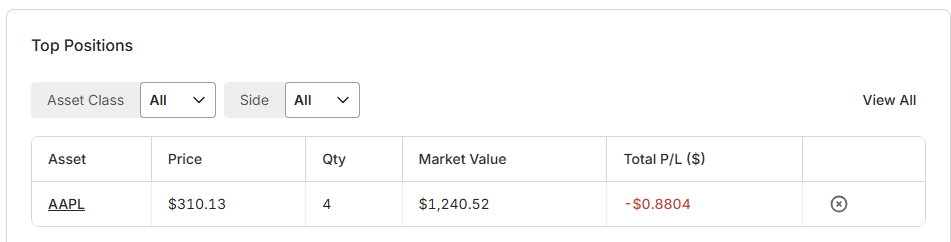

yo personalmente compré 2 anteriormente y otras 2 ahora, por eso aparecen 4

## Crear y Enviar una Órden de Venta (Market Order)
Para enviar órdenes, usamos MarketOrderRequest (u otros tipos como LimitOrderRequest) junto con las constantes de configuración.

In [ ]:
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

# Configurar los parámetros de la orden para VENDER 2 acciones de Apple (AAPL)
market_order_data = MarketOrderRequest(
    symbol="AAPL",
    qty=2,
    side=OrderSide.SELL,  # <--- Cambiado de BUY a SELL
    time_in_force=TimeInForce.DAY
)

# Enviar la orden de venta al mercado
market_order = trading_client.submit_order(order_data=market_order_data)
print(f"Orden de venta enviada con éxito. ID de la orden: {market_order.id}")

Orden de venta enviada con éxito. ID de la orden: 6571b5d4-ac8b-470a-b74c-3072bc194e66


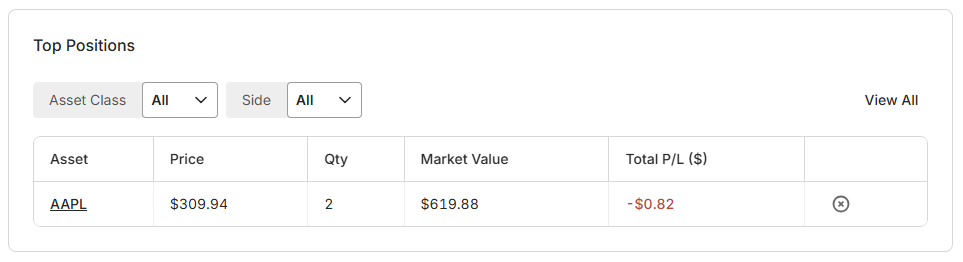

Despues de ejecutar la venta de 2 acciones, todavía me quedan las otras 2. El criterio de liquidacion es FIFO (First In First Out).

### Crear una Orden Limite

Para ejecutar una orden a un precio específico y no al precio actual de mercado, debes utilizar una Orden Límite (`LimitOrderRequest`).

A diferencia de las órdenes de mercado (Market Orders), que se ejecutan inmediatamente al precio que esté disponible, las órdenes límite te permiten establecer el precio máximo que estás dispuesto a pagar (si compras) o el precio mínimo que estás dispuesto a aceptar (si vendes). La orden solo se ejecutará si el mercado alcanza ese precio o uno mejor.

Aquí tienes cómo estructurar y enviar una orden límite usando `alpaca-py`

In [ ]:
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import LimitOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

# Configurar la orden límite de COMPRA
# Supongamos que AAPL cotiza a $180, pero tú solo quieres comprar si baja a $175
limit_order_data = LimitOrderRequest(
    symbol="AAPL",
    qty=5,                          # Cantidad de acciones
    limit_price=175.00,             # <--- EL PRECIO CONCRETO OBJETIVO
    side=OrderSide.BUY,             # Compra // SELL para venta
    time_in_force=TimeInForce.DAY   # La orden se cancela al fin del día si no se ejecuta
)

In [ ]:
# Enviar la orden a Alpaca
limit_order = trading_client.submit_order(order_data=limit_order_data)
print(f"Orden Límite enviada. ID: {limit_order.id} | Estado: {limit_order.status}")

**¿Cómo funcionan los límites según la operación?**

**Compra Límite (Buy Limit)**: Se ejecuta solo si el precio cae al precio límite establecido o menos. Evita que pagues de más en momentos de alta volatilidad.

**Venta Límite (Sell Limit)**: Se ejecuta solo si el precio sube al precio límite establecido o más. Se utiliza normalmente para fijar un objetivo de toma de ganancias (Take Profit).

**Gestión de Órdenes Pendientes (Modificar o Cancelar)**

Dado que las órdenes límite no se ejecutan inmediatamente, se quedan en el estado de "Pendientes" (Open / Pending). Con `alpaca-py` puedes gestionarlas antes de que se llenen:

In [ ]:
# Cancelar orden pendiente
trading_client.cancel_order_by_id(limit_order.id)
print("Orden cancelada con éxito.")

In [ ]:
# ver ordenes pendientes
from alpaca.trading.requests import GetOrdersRequest
from alpaca.trading.enums import QueryOrderStatus

# Filtramos para ver solo las órdenes que siguen abiertas
filter_params = GetOrdersRequest(status=QueryOrderStatus.OPEN)
open_orders = trading_client.get_orders(filter_params)

for order in open_orders:
    print(f"Pendiente: {order.side} {order.qty} {order.symbol} a un precio límite de ${order.limit_price}")

### Revisar Posiciones Activas

Una vez que la orden se ejecuta, puedes ver qué activos tienes en cartera.

In [ ]:
# Obtener todas las posiciones abiertas
positions = trading_client.get_all_positions()

for position in positions:
    print(f"Activo: {position.symbol} | Cantidad: {position.qty} | Valor Actual: ${position.market_value}")

Activo: AAPL | Cantidad: 2 | Valor Actual: $619.74


In [ ]:
positions

[{   'asset_class': <AssetClass.US_EQUITY: 'us_equity'>,
     'asset_id': UUID('b0b6dd9d-8b9b-48a9-ba46-b9d54906e415'),
     'asset_marginable': True,
     'avg_entry_price': '310.35',
     'avg_entry_swap_rate': None,
     'change_today': '0.0034',
     'cost_basis': '620.7',
     'current_price': '309.87',
     'exchange': <AssetExchange.NASDAQ: 'NASDAQ'>,
     'lastday_price': '308.82',
     'market_value': '619.74',
     'qty': '2',
     'qty_available': '2',
     'side': <PositionSide.LONG: 'long'>,
     'swap_rate': None,
     'symbol': 'AAPL',
     'unrealized_intraday_pl': '-0.96',
     'unrealized_intraday_plpc': '-0.00155',
     'unrealized_pl': '-0.96',
     'unrealized_plpc': '-0.00155',
     'usd': None}]

### 4. Obtención de Datos de Mercado (Históricos)
Para alimentar un algoritmo, necesitas datos. alpaca-py separa los datos en `StockHistoricalDataClient` (Acciones) y `CryptoHistoricalDataClient` (Criptomonedas).

Aquí veremos cómo pedir barras de precio (velas) para acciones japonesas o americanas, en este caso, Apple y Tesla.

In [ ]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime

# El cliente de datos solo requiere autenticación básica
data_client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

# Configurar la petición de datos
request_params = StockBarsRequest(
    symbol_or_symbols=["AAPL", "TSLA"],
    timeframe=TimeFrame.Day,                    # Velas diarias
    start=datetime(2025, 1, 1),                  # Fecha de inicio
    end=datetime(2025, 12, 31)                   # Fecha de fin
)

# Descargar las barras
bars = data_client.get_stock_bars(request_params)

# ¡Ventaja de alpaca-py! Puedes convertir los datos directamente a un DataFrame de Pandas
bars_df = bars.df
print(bars_df.head())

                                    open      high       low   close  \
symbol timestamp                                                       
AAPL   2025-01-02 05:00:00+00:00  248.93  249.1000  241.8201  243.85   
       2025-01-03 05:00:00+00:00  243.36  244.1800  241.8900  243.36   
       2025-01-06 05:00:00+00:00  244.31  247.3300  243.2000  245.00   
       2025-01-07 05:00:00+00:00  242.98  245.5500  241.3500  242.21   
       2025-01-08 05:00:00+00:00  241.92  243.7123  240.0500  242.70   

                                      volume  trade_count        vwap  
symbol timestamp                                                       
AAPL   2025-01-02 05:00:00+00:00  55740731.0     685448.0  244.339399  
       2025-01-03 05:00:00+00:00  40244114.0     493786.0  243.069441  
       2025-01-06 05:00:00+00:00  45045571.0     493920.0  245.239060  
       2025-01-07 05:00:00+00:00  40855960.0     462887.0  243.011137  
       2025-01-08 05:00:00+00:00  37628940.0     406916.0  242.

<Axes: xlabel='timestamp'>

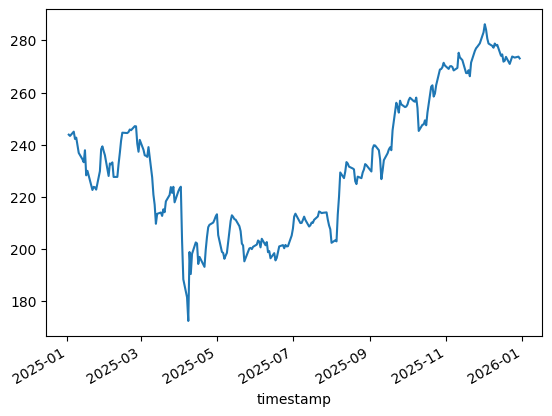

In [ ]:
# dataframe multi-indice, lo filtramos por 1 solo indice
bars_df.xs('AAPL')['close'].plot()

<Axes: xlabel='timestamp'>

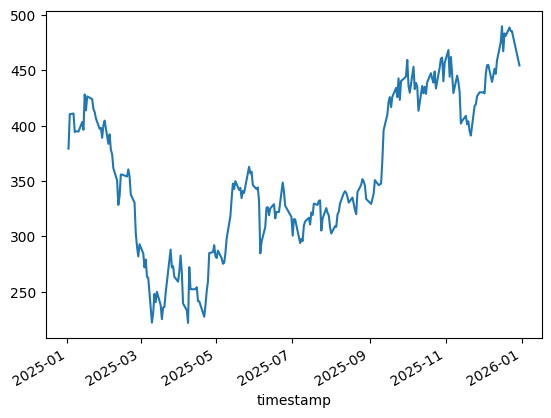

In [ ]:
# dataframe multi-indice, lo filtramos por 1 solo indice
bars_df.xs('TSLA')['close'].plot()

**Nota**: El DataFrame devuelto tiene un índice compuesto (MultiIndex) por symbol y timestamp, lo que facilita enormemente el análisis técnico automatizado.

### 5. Datos en Tiempo Real (WebSockets)
Si quieres que tu bot reaccione al instante cuando el precio cambie, necesitas el cliente de streaming. Este cliente funciona de manera asíncrona mediante async/await.

Aquí tienes un script funcional para escuchar los trades (operaciones ejecutadas) de Bitcoin en tiempo real:

In [ ]:
import asyncio
from alpaca.data.live import CryptoDataStream
import nest_asyncio

nest_asyncio.apply()

# Inicializar el stream de criptomonedas
stream = CryptoDataStream(API_KEY, SECRET_KEY)

# Definir una función (handler) que procesará los datos entrantes
async def handle_trade(data):
    print(f"¡Nueva operación! {data.symbol}: Precio ${data.price} | Cantidad: {data.size}")

# Suscribirse al canal de operaciones (trades) para Bitcoin
stream.subscribe_trades(handle_trade, "BTC/USD")

# Iniciar el bucle de ejecución
print("Escuchando el mercado en tiempo real...")
stream.run()

Escuchando el mercado en tiempo real...
keyboard interrupt, bye


TimeoutError: 

## 6. Código Completo: Extracción y Visualización
Aquí tienes un script completo que extrae las tres temporalidades requeridas para una acción (por ejemplo, Apple - AAPL) y grafica cada una de ellas.

In [ ]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.data.enums import DataFeed
from datetime import datetime, timedelta, timezone
import pandas as pd

In [ ]:
symbol = "AAPL"

In [ ]:
# 1. Aseguramos un retraso de 15-20 minutos para evitar el bloqueo de datos recientes
ahora_con_retraso = datetime.now(timezone.utc) - timedelta(minutes=20)
inicio = ahora_con_retraso - timedelta(days=3)

# 2. Agregamos el parámetro 'feed=DataFeed.IEX'
request_params = StockBarsRequest(
    symbol_or_symbols="AAPL",
    timeframe=TimeFrame.Minute,
    start=inicio,
    end=ahora_con_retraso,
    feed=DataFeed.IEX  # <--- CRUCIAL: Esto le dice a Alpaca que use el feed gratuito
)

bars = data_client.get_stock_bars(request_params)

In [ ]:
bars

{   'data': {   'AAPL': [   {   'close': 310.77,
                                'high': 310.77,
                                'low': 310.77,
                                'open': 310.77,
                                'symbol': 'AAPL',
                                'timestamp': datetime.datetime(2026, 5, 26, 12, 3, tzinfo=TzInfo(0)),
                                'trade_count': 2.0,
                                'volume': 100.0,
                                'vwap': 310.77},
                            {   'close': 310.91,
                                'high': 310.91,
                                'low': 310.89,
                                'open': 310.89,
                                'symbol': 'AAPL',
                                'timestamp': datetime.datetime(2026, 5, 26, 12, 11, tzinfo=TzInfo(0)),
                                'trade_count': 4.0,
                                'volume': 160.0,
                                'vwap': 310.9025},
         

<Axes: title={'center': 'AAPL Close Price'}, xlabel='timestamp'>

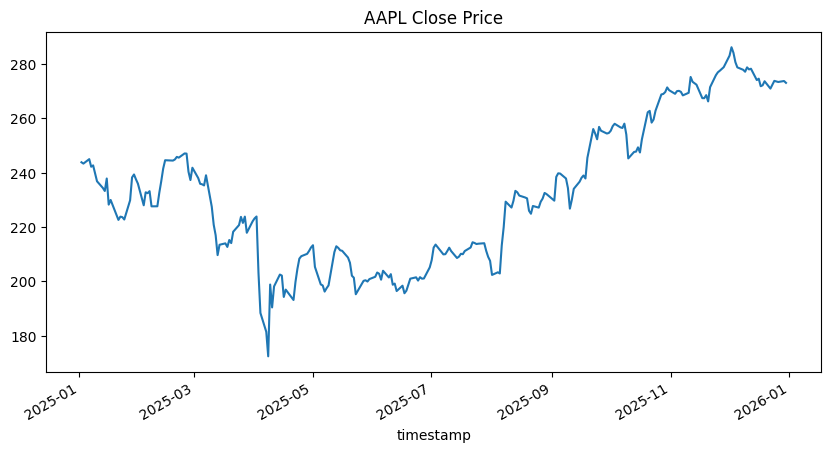

In [ ]:
# Grafica el precio de cierre de Apple directamente en una línea de código
bars_df.xs('AAPL')['close'].plot(title="AAPL Close Price", figsize=(10,5))